In [ ]:
from datasets import load_dataset
import pandas as pd

# Load the dataset from Hugging Face
# This dataset only has a 'train' split
dataset = load_dataset("adityarane/financial-qa-dataset", split='train', verification_mode="no_checks")

# Convert the Dataset object to a pandas DataFrame
df = dataset.to_pandas()

# Display the first few rows of the DataFrame
print(df.head())

In [135]:
from typing import Sequence
import dataclasses
import json
from vertexai import generative_models

PROMPT = """
Answer the question given the context.

EXAMPLE:

Query: What is Bob's dog's name?
Context: Bob grew up with a dog that his parents bought him for his 2nd birthday. His name was Lucky.

Answer: 

Bob's dog's name is Lucky
"""

PROMPT_INCORRECT = """
Answer the question incorrectly given the context.

EXAMPLE:

Query: What is Bob's dog's name?
Context: Bob grew up with a dog that his parents bought him for his 2nd birthday. His name was Lucky.

Answer: 

Bob's dog's name is Tango
"""

RESPONSE_SCHEMA_SCORE = {
    "type": "object",
    "properties": {
        "answer": {"type": "string"},
    },
    "required": ["answer"],
}


# @dataclasses.dataclass(frozen=True)
# class GenerationEvaluation:
#   """The generation evaluation result.

#   Attributes:
#     score: The score of the generation evaluation.
#     reason: The reason of the generation evaluation.
#   """
#   score: float
#   reason: str


def answer_question(
    model: generative_models.GenerativeModel,
    question: Sequence[generative_models.Part],
    context: Sequence[generative_models.Part],
    is_correct: bool
) -> str:
  """Answer the question given the context.

  Args:
    model: The model to use.
    question: The question to ask the model.
    context: The context to ground the question in.

  Returns:
    The answer.
  """
  part_list = []
  part_list.append(
      generative_models.Part.from_text(
          PROMPT if is_correct else PROMPT_INCORRECT
      )
  )

  part_list.append(generative_models.Part.from_text("\nQuery: "))
  for part in question:
    part_list.append(part)

  part_list.append(generative_models.Part.from_text("\Context: "))
  for part in context:
    part_list.append(part)

  response: generative_models.GenerationResponse = (
      model.generate_content(
          part_list,
          generation_config=generative_models.GenerationConfig(
              temperature=0,
              response_mime_type="text/plain",
            #   response_schema=RESPONSE_SCHEMA_SCORE,
          ),
      )
  )
#   score_eval_response_dict = json.loads(response.candidates[0].text)
#   eval_result = GenerationEvaluation(
#       score=score_eval_response_dict["score"],
#       reason=score_eval_response_dict["reason"],
#   )
  answer = response.candidates[0].text
  return answer.strip().removeprefix("Answer:").strip()

In [ ]:
import vertexai
vertexai.init(project="ivanmkc-experimental-2-631260")

In [136]:
import asyncio
from async_lru import alru_cache

model_name = "gemini-2.5-pro"
model: generative_models.GenerativeModel = generative_models.GenerativeModel(
    model_name=model_name,
)

/Users/ivanmkc/code/adk-samples/env/lib/python3.11/site-packages/vertexai/generative_models/_generative_models.py:433: UserWarning: This feature is deprecated as of June 24, 2025 and will be removed on June 24, 2026. For details, see https://cloud.google.com/vertex-ai/generative-ai/docs/deprecations/genai-vertexai-sdk.
  warning_logs.show_deprecation_warning()


In [137]:

question = "What is the capital of QWERBDA"
context = "QWERBDA's capital is 3MWdfo"

@alru_cache(maxsize=None)
async def answer_question_async(question: str, context: str, is_correct: bool, semaphore: asyncio.Semaphore) -> str:
    async with semaphore:
        return await asyncio.to_thread(answer_question,
            model=model,
            question=[generative_models.Part.from_text(question)],
            context=[generative_models.Part.from_text(context)],
            is_correct=is_correct
        )

In [138]:
await answer_question_async(question=question, context=context, is_correct=False, semaphore=asyncio.Semaphore(10))

'The capital of QWERBDA is Portsmith'

## Set up RAG engine

In [ ]:
# Upload local folder to GCS
local_root_path = "/Users/ivanmkc/code/adk-samples/output/financial-qa-eda/"

# Copy
gcs_path = "gs://ivanmkc-test3/financial-qa-eda/"

In [ ]:
# import os

# # Create the directory if it doesn't exist
# os.makedirs(local_root_path, exist_ok=True)

# # Write each context to its own file in the specified directory
# for i, context in enumerate(contexts):
#     # Define a unique filename for each context
#     filename = os.path.join(local_root_path, f"context_{i}.txt")
    
#     # Use a 'with' statement to handle file opening and closing automatically
#     try:
#         with open(filename, "w", encoding="utf-8") as f:
#             # Write the context to its own file
#             f.write(context)
#         print(f"Successfully wrote to {filename}")
#     except IOError as e:
#         print(f"Error writing to file {filename}: {e}")



In [ ]:
# ! gsutil -m cp -r {local_root_path} {gcs_path}

In [ ]:
# import importlib

# importlib.reload(vertexai)
# importlib.reload(vertexai.generative_models)
# importlib.reload(vertexai.preview)
# importlib.reload(vertexai.generative_models)
# importlib.reload(vertexai.preview.rag.utils.resources)
# # importlib.reload(rag)

In [ ]:
import google.cloud.aiplatform as aiplatform

# Create Index
index = aiplatform.MatchingEngineIndex.create_tree_ah_index(
    display_name="financial-qa",
    # contents_delta_uri=gcs_uri,
    description="financial-qa index",
    dimensions=768,
    approximate_neighbors_count=150,
    leaf_node_embedding_count=500,
    leaf_nodes_to_search_percent=7,
    index_update_method="STREAM_UPDATE",  # Options: STREAM_UPDATE, BATCH_UPDATE
    distance_measure_type=aiplatform.matching_engine.matching_engine_index_config.DistanceMeasureType.DOT_PRODUCT_DISTANCE,
)


In [ ]:
# Create Index Endpoint
index_endpoint = aiplatform.MatchingEngineIndexEndpoint.create(
    display_name="financial-qa index endpoint",
    public_endpoint_enabled=True,
    description="financial-qa index endpoint",
)

In [ ]:
# Deploy Index to Endpoint
index_endpoint = index_endpoint.deploy_index(
    index=index, deployed_index_id="financial_qa_deployed_index_3"
)

In [ ]:
# index_endpoint.undeploy_all()
# index_endpoint.delete()
# index.delete()

In [ ]:
from vertexai.preview import rag
from vertexai.preview.rag.utils.resources import EmbeddingModelConfig, RagManagedDb, ANN, VertexVectorSearch
import vertexai

# Create a RAG Corpus, Import Files, and Generate a response
# Initialize Vertex AI API once per session
PROJECT_ID = "ivanmkc-test"
vertexai.init(project=PROJECT_ID, location="us-central1")

display_name = "financial-qa-2"
paths = [gcs_path]

# Create RagCorpus
# Configure embedding model, for example "text-embedding-005".
embedding_model_config = EmbeddingModelConfig(
    publisher_model="publishers/google/models/text-embedding-005"
    )

vector_db = VertexVectorSearch(
    index=index.resource_name,
    index_endpoint=index_endpoint.resource_name
)
# vector_db = RagManagedDb(
#             retrieval_strategy=ANN()
#         )

rag_corpus = rag.create_corpus(
    display_name=display_name,
    embedding_model_config=embedding_model_config,
    vector_db=vector_db
)

# Import Files to the RagCorpus
rag.import_files(
    rag_corpus.name,
    paths,
    # Optional
    transformation_config=rag.TransformationConfig(
        chunking_config=rag.ChunkingConfig(
            chunk_size=512,
            chunk_overlap=100,
        ),
    ),
    max_embedding_requests_per_min=1000,  # Optional
)


In [ ]:
rag_corpus.name

## Step 1: Generate responses for the dataset. 

- Input: Question column, Context column (no answer column)
- Output: Gemini generates a response to the question.

In [141]:
import random
random.seed(4)

questions, answers, contexts = df['Questions'], df['Answers'], df['Contexts']
is_corrects = [random.choice([True, False]) for _ in questions]

semaphore = asyncio.Semaphore(10)
gemini_answers = await asyncio.gather(*[answer_question_async(
            question=question,
            context=context,
            is_correct=is_correct,
            semaphore=semaphore
        )
        for question, is_correct, context in zip(questions, is_corrects, contexts)]
    )

## Step 2: Score the response.
- Input: Question column, Context column, and answer column and response from Step 1.
- Output: Score from 0.0 to 5.0.

In [142]:
import dotenv
dotenv.load_dotenv()

from vertexai import generative_models

model_name = "gemini-2.5-pro"
model: generative_models.GenerativeModel = generative_models.GenerativeModel(
    model_name=model_name,
)

/Users/ivanmkc/code/adk-samples/env/lib/python3.11/site-packages/vertexai/generative_models/_generative_models.py:433: UserWarning: This feature is deprecated as of June 24, 2025 and will be removed on June 24, 2026. For details, see https://cloud.google.com/vertex-ai/generative-ai/docs/deprecations/genai-vertexai-sdk.
  warning_logs.show_deprecation_warning()


In [ ]:
import asyncio
from autorater import eval_generation_async

autorater_scores_for_gemini_answers = await asyncio.gather(*[eval_generation_async(
        model=model,
        question=question,
        model_reply=answer, 
        ground_truth=context,
        semaphore=semaphore)
        for question, answer, context in zip(questions, gemini_answers, contexts)]
    )


## Step 3: Critique and revise.
- Input: Question column, Context column, and response from Step 1 (no answer column)
- Output: revised response

In [ ]:
rag_corpus.name

In [ ]:
from llm_auditor import agent

llm_auditor = agent.create_llm_auditor(
    agent_name="llm_auditor_financial",
    critic_agent_name="critic_agent_financial",
    reviser_agent_name="reviser_agent_financial",
    rag_corpus_id=rag_corpus.name
)

Invalid config for agent format_agent: output_schema cannot co-exist with agent transfer configurations. Setting disallow_transfer_to_parent=True, disallow_transfer_to_peers=True


In [ ]:
import revise

import importlib
importlib.reload(revise)
# from llm_auditor import agent
# auditor_agent = agent.create_llm_auditor()

reviser = revise.ClaimReviser(llm_auditor=llm_auditor)

revised_gemini_answers = await asyncio.gather(*[reviser.revise_claim_async(
        claim=answer,
        semaphore=semaphore)
        for _, answer, _ in zip(questions, gemini_answers, contexts)]
    )

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY 

An error occurred during evaluation of 'The cash used in financing activities by Apple Inc. in 2019 was (90,976) million.': 400 INVALID_ARGUMENT. {'error': {'code': 400, 'message': 'Request contains an invalid argument.', 'status': 'INVALID_ARGUMENT'}}


Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY 

An error occurred during evaluation of 'The total comprehensive income of Mercedes-Benz Group in 2022 was 19,146 million euros.': 400 INVALID_ARGUMENT. {'error': {'code': 400, 'message': 'Request contains an invalid argument.', 'status': 'INVALID_ARGUMENT'}}


Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY 

...

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY 

An error occurred during evaluation of 'The total current liabilities of the BMW Group in 2021 were €76,466 million.': 400 INVALID_ARGUMENT. {'error': {'code': 400, 'message': 'Request contains an invalid argument.', 'status': 'INVALID_ARGUMENT'}}


Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY 

An error occurred during evaluation of 'The total retained earnings of Apple Inc. at the end of 2019 was $45,898 million.': 400 INVALID_ARGUMENT. {'error': {'code': 400, 'message': 'Request contains an invalid argument.', 'status': 'INVALID_ARGUMENT'}}


Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


In [ ]:
for x, y in list(zip(gemini_answers, revised_gemini_answers))[:40]:
    print(f"before: {x}, after: {y}")

before: The total revenue of Alphabet Inc. in the year 2023 was $307,394 million., after: The total revenue of Alphabet Inc. in the year 2023 was $307,394 million.

before: The BMW Group reported €10,932 million in trade payables in 2021., after: Based on the provided sources, I cannot confirm that the BMW Group reported €10,932 million in trade payables in 2021.

before: The total equity attributable to shareholders of BMW AG in 2019 was €59,324 million., after: According to the provided sources, the total equity attributable to shareholders of BMW AG in 2019 was €59,324 million.

before: The amount of subscribed share capital increase out of Authorised Capital in BMW Group during 2020 was €1 million., after: The subscribed share capital increase out of Authorised Capital in BMW Group during 2020 was €1 million.

before: The revenue of Mercedes-Benz Group in 2022 was 150,017 million euros., after: According to the provided sources, the revenue of Mercedes-Benz Group in 2022 was 150,01

## Step 4: Score the revised response.
- Input: Question column, Context column, and answer column and response from Step 3.
- Output: Score from 0.0 to 5.0.

In [ ]:
import autorater

# importlib.reload(eval_generation_async)
# importlib.reload(autorater)
from autorater import eval_generation_async, GenerationEvaluation


In [ ]:
async def eval_generation_async_optional(
   model: generative_models.GenerativeModel, 
   question: str, 
   model_reply: str, 
   ground_truth: str, 
   semaphore: asyncio.Semaphore) -> GenerationEvaluation | None:
    if not model_reply:
        return None
    
    return await eval_generation_async(
        model=model,
        question=question,
        model_reply=model_reply, 
        ground_truth=ground_truth,
        semaphore=semaphore)
    

In [ ]:
autorater_scores_for_revised_gemini_answers = await asyncio.gather(*[eval_generation_async_optional(
        model=model,
        question=question,
        model_reply=answer, 
        ground_truth=context,
        semaphore=semaphore)
        for question, answer, context in zip(questions, revised_gemini_answers, contexts)]
    )


In [ ]:
autorater_scores_for_revised_gemini_answers

[GenerationEvaluation(score=5.0, reason="The generated response is perfectly accurate. It correctly states the total revenue of Apple Inc. in 2023 as $383,285 million, which matches the 'Net sales' figure for the year 2023 in the provided ground truth document."),
 GenerationEvaluation(score=0.0, reason="The generated response is incorrect. It claims that it cannot confirm the value of €10,932 million for trade payables in 2021. However, the ground truth document clearly shows on the line item 'Trade payables' under the 'Group' column for '2021' that the value is indeed 10,932 (in € million). The model failed to extract the correct information from the provided source."),
 GenerationEvaluation(score=5.0, reason='The generated response is perfectly accurate. It correctly identifies the value for "Equity attributable to shareholders of BMW AG" for the year 2019 from the provided financial statement. The value of €59,324 million is correct according to the ground truth table.'),
 Generati

In [ ]:
df_results = pd.DataFrame([dict(question=question, 
                   answer=answer,
                   context=context,
                   score=score.score if score else None,
                   reason=score.reason if score else None,
                   is_correct=is_correct,
                   revised_answer=revised_answer,
                   revised_score=revised_score.score if revised_score else None,
                   revised_reason=revised_score.reason if revised_score else None,
                   ) 
              for (question, context, answer, is_correct, revised_answer, score, revised_score) in zip(questions, contexts, answers, is_corrects, revised_gemini_answers, autorater_scores_for_gemini_answers, autorater_scores_for_revised_gemini_answers)
              ])

In [122]:
df_results.to_csv("financial-qa-results.csv")

## Show interaction of original vs revised and its effect on scores

In [123]:
import seaborn as sns

# To use the index, we first turn it into a column
df_reset = df_results.reset_index()

# Now, convert this to a long-form DataFrame for Seaborn
df_long = pd.melt(df_reset, id_vars=['index'], value_vars=['score', 'revised_score'],
                  var_name='line_name', value_name='score_value')

print("Long-form DataFrame ready for plotting:")
print(df_long.head())

Long-form DataFrame ready for plotting:
   index line_name  score_value
0      0     score          5.0
1      1     score          5.0
2      2     score          5.0
3      3     score          5.0
4      4     score          5.0


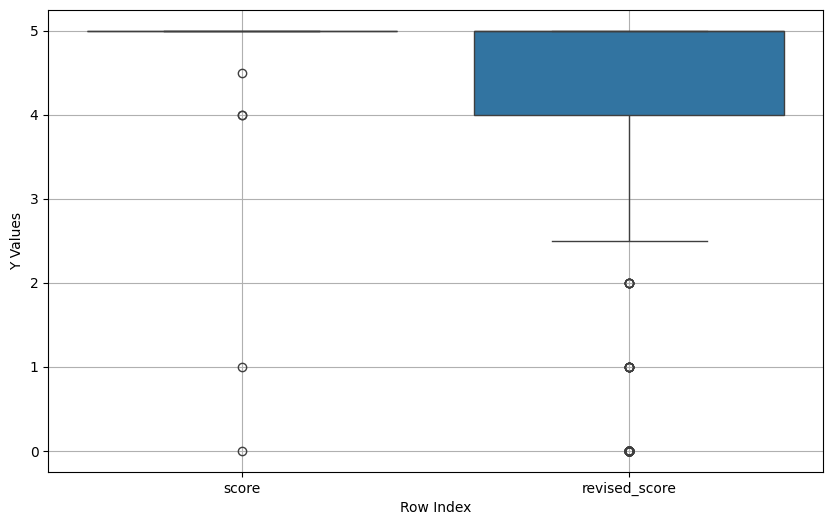

In [124]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_long,
    x='line_name',        # Use the reset index for the x-axis
    y='score_value',
    # hue='is_supported',  # Different colors for 'line1_data' and 'line2_data'
    # style='is_supported'  # Different line styles for categories 'A' and 'B'
)

plt.xlabel('Row Index')
plt.ylabel('Y Values')
# plt.legend(title='is_supported')
plt.grid(True)
plt.show()

# Autorater score histograms

Another way to view it.

As expected, the revised_score shifts all the scores to 5.0 since it's rewriting is_supported == False statements to True.

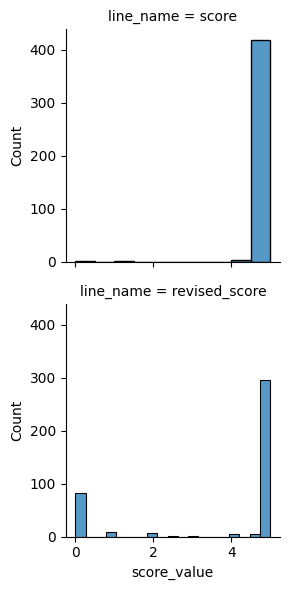

In [125]:
g = sns.FacetGrid(data=df_long, col='line_name', col_wrap=1)
g.map(sns.histplot, 'score_value')

In [126]:
df_long.groupby(["line_name"])["score_value"].mean()

line_name
revised_score    3.814815
score            4.972749
Name: score_value, dtype: float64

## Improvement of revised_score over score

Let's show that baseline gets a score of X then after revision we get a score of Y > X.
Where the score is based on this prompt.

In [127]:
df_results["revised_score_is_higher"] = df_results["revised_score"] > df_results["score"]

In [128]:
len(df_results[df_results["revised_score_is_higher"]])/len(df_results)

0.004739336492890996

In [131]:
for _, row in df_results[df_results["revised_score"] < df_results["score"]].sample(10).iterrows():
    print(f"question: {row.question}\n\tbefore ({row.score}): {row.answer}\n\tafter ({row.revised_score}): {row.revised_answer}\n")

question: How much cash inflow or outflow did BMW Group experience from investing activities in 2021?
	before (5.0): € -6,208 million
	after (0.0): BMW Group experienced a cash outflow of €6,735 million from financing activities in 2021.


question: What amount of cash did NVIDIA pay for income taxes in 2023?
	before (5.0): $1,404 million
	after (0.0): Based on the provided sources, NVIDIA's income tax expense (benefit) for the year ended January 29, 2023, was reported as a benefit of $(187) million, not an expense of $1,404 million.


question: How much cash did NVIDIA use to repurchase stock in the year ended January 30, 2022?
	before (5.0): $399 million
	after (0.0): The provided context does contain information about the amount of cash NVIDIA used to repurchase stock.


question: What was the net profit/loss for BMW AG in 2020?
	before (5.0): €3,857 million
	after (0.0): The net profit for BMW AG in 2020 was €3,775 million.


question: How much did Alphabet Inc. gain or lose from a